# Classificação de Vulnerabilidade Institucional no Sistema Prisional Brasileiro

**Dataset:** SISDEPEN — 18º Ciclo (1º Semestre de 2025)  
**Fonte:** Departamento Penitenciário Nacional (DEPEN) — dados.gov.br  
**Modelos:** Árvore de Decisão, SVM e Rede Neural (MLP)  
**Problema:** Classificação multiclasse supervisionada (baixa / média / alta vulnerabilidade)

## 1. Importação das Bibliotecas

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

print('Versões das bibliotecas:')
print(f'  pandas:  {pd.__version__}')
print(f'  numpy:   {np.__version__}')

Versões das bibliotecas:
  pandas:  3.0.1
  numpy:   2.4.4


## 2. Carregamento e Exploração do Dataset

O dataset é o SISDEPEN 18º ciclo, com dados de **1.555 estabelecimentos prisionais** brasileiros.
O arquivo está separado por ponto e vírgula (`;`) e codificado em `latin-1` (padrão de arquivos governamentais brasileiros).

In [134]:
df = pd.read_csv(
    '18o-ciclo-base-de-dados-2025-1-semestre.csv',
    sep=';',
    encoding='latin-1',
    low_memory=False
)

# Corrigir encoding dos nomes das colunas e dos valores de texto
df.columns = [c.encode('latin-1').decode('utf-8', errors='replace') for c in df.columns]

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].apply(lambda x: x.encode('latin-1').decode('utf-8', errors='replace') if isinstance(x, str) else x)

print(f'Número de estabelecimentos (linhas): {df.shape[0]}')
print(f'Número de variáveis (colunas):       {df.shape[1]}')

Número de estabelecimentos (linhas): 1555
Número de variáveis (colunas):       1737


### 2.1 Visão geral das colunas de identificação

In [135]:
colunas_id = ['Tipo do Estabelecimento', 'Âmbito', 'UF', 'Situação do Estabelecimento']

for col in colunas_id:
    print(f'--- {col} ---')
    print(df[col].value_counts().to_string())
    print()

--- Tipo do Estabelecimento ---
Tipo do Estabelecimento
Cela física                                1380
Domiciliar sem monitoramento eletrônico     110
Domiciliar com monitoramento eletrônico      65

--- Âmbito ---
Âmbito
Estadual    1550
Federal        5

--- UF ---
UF
MG    220
SP    181
PR    125
RS    112
PE     84
GO     83
RO     75
PB     63
ES     59
MA     56
PA     56
SC     55
RJ     54
MS     52
MT     42
AM     33
CE     33
RN     30
BA     27
TO     27
PI     18
AC     16
AL     13
AP     11
SE     11
DF     10
RR      9

--- Situação do Estabelecimento ---
Situação do Estabelecimento
Ativo    1555



### 2.2 Distribuição por estado

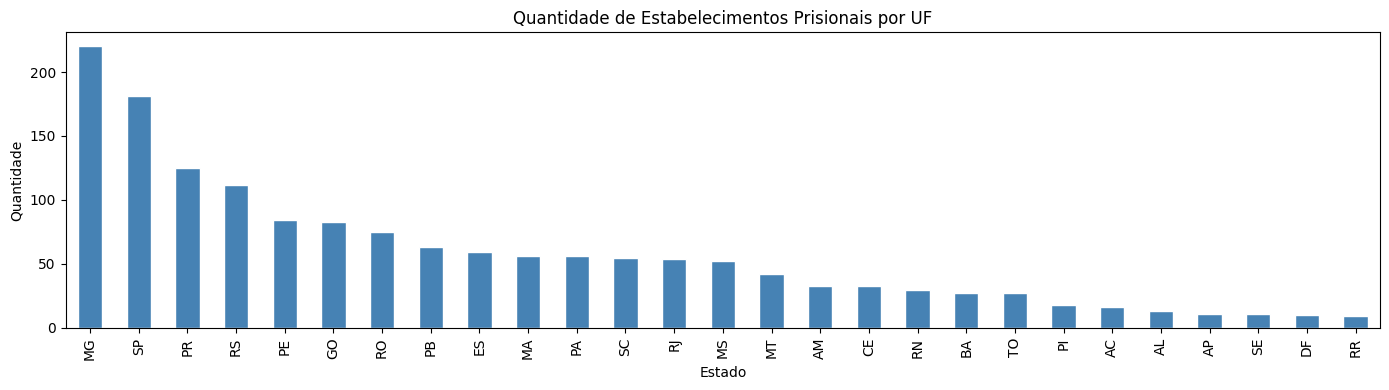

In [136]:
plt.figure(figsize=(14, 4))
df['UF'].value_counts().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Quantidade de Estabelecimentos Prisionais por UF')
plt.xlabel('Estado')
plt.ylabel('Quantidade')
plt.tight_layout()
plt.show()

### 2.3 Filtro: apenas estabelecimentos de cela física

O dataset inclui prisões domiciliares (com e sem monitoramento eletrônico). Esses registros não possuem estrutura física — sem módulo de saúde, sem psicólogo, sem capacidade de vagas — o que distorceria o índice de vulnerabilidade. Por isso mantemos apenas os estabelecimentos de cela física.

In [137]:
print('Distribuição por tipo de estabelecimento:')
print(df['Tipo do Estabelecimento'].value_counts().to_string())
print(f'\nTotal: {len(df)} estabelecimentos')

Distribuição por tipo de estabelecimento:
Tipo do Estabelecimento
Cela física                                1380
Domiciliar sem monitoramento eletrônico     110
Domiciliar com monitoramento eletrônico      65

Total: 1555 estabelecimentos


In [138]:
print(f'Total antes do filtro: {len(df)} estabelecimentos')

df = df[df['Tipo do Estabelecimento'] == 'Cela física'].copy()
df = df.reset_index(drop=True)

print(f'Total após o filtro:   {len(df)} estabelecimentos')
print(f'Removidos:             {1555 - len(df)} prisões domiciliares')

Total antes do filtro: 1555 estabelecimentos
Total após o filtro:   1380 estabelecimentos
Removidos:             175 prisões domiciliares


### 2.4 Valores ausentes nas colunas que serão usadas

Das 1.737 colunas do dataset, utilizaremos apenas as relevantes para construir o índice de vulnerabilidade (y) e as features do modelo (X). Abaixo verificamos a quantidade de valores ausentes nessas colunas para decidir como tratá-los.

In [139]:
colunas_relevantes = {
    # --- Componentes do y (índice de vulnerabilidade) ---
    'cap_total_provisorios':  '1.3 Capacidade do estabelecimento | Presos provisórios | Total',
    'cap_total_fechado':      '1.3 Capacidade do estabelecimento | Regime fechado | Total',
    'cap_total_semiaberto':   '1.3 Capacidade do estabelecimento | Regime semiaberto | Total',
    'cap_total_aberto':       '1.3 Capacidade do estabelecimento | Regime aberto | Total',
    'cap_total_rdd':          '1.3 Capacidade do estabelecimento | Regime Disciplinar Diferenciado (RDD) | Total',
    'cap_total_medida':       '1.3 Capacidade do estabelecimento | Medidas de segurança de internação | Total',
    'pop_total':              '4.1 População prisional | Total',
    'psicologos':             '3.1 Quantidade de Servidores que atuam no Sistema Prisional | Psicólogos | Total',
    'obitos_criminais':       '6.8 Mortalidade no Sistema Prisional (total do período) | Óbitos criminais | Total',
    'obitos_suicidios':       '6.8 Mortalidade no Sistema Prisional (total do período) | Óbitos suicídios | Total',
    'sem_assistencia_jur':    '3.3 Há prestação sistemática de assistência jurídica gratuita às pessoas privadas de liberdade neste estabelecimento? | Sim, por meio da Defensoria Pública',
    'sem_modulo_saude':       '2.4 Módulo de saúde | Não possui módulo de saúde',
    # --- Features do X ---
    'assist_sociais':         '3.1 Quantidade de Servidores que atuam no Sistema Prisional | Assistentes sociais | Total',
    'medicos':                '3.1 Quantidade de Servidores que atuam no Sistema Prisional | Médicos - clínicos gerais | Total',
    'enfermeiros':            '3.1 Quantidade de Servidores que atuam no Sistema Prisional | Enfermeiros | Total',
    'professores':            '3.1 Quantidade de Servidores que atuam no Sistema Prisional | Professores | Total',
    'advogados':              '3.1 Quantidade de Servidores que atuam no Sistema Prisional | Advogados | Total',
    'insp_mp':                '7.5 Foi realizada visita(s) de inspeção no período de referência? | Ministério Público',
    'insp_defensoria':        '7.5 Foi realizada visita(s) de inspeção no período de referência? | Defensoria Pública',
    'insp_judiciario':        '7.5 Foi realizada visita(s) de inspeção no período de referência? | Judiciário',
    'visitantes':             '5.11 Número de pessoas privadas de liberdade que possuem visitantes cadastrados | Pessoas com visitantes cadastrados | Masculino',
    'hiv':                    '6.7 Quantidade de pessoas com agravos transmissíveis na data de fim do período de referência | HIV | Total',
    'tuberculose':            '6.7 Quantidade de pessoas com agravos transmissíveis na data de fim do período de referência | Tuberculose | Total',
    'sifilis':                '6.7 Quantidade de pessoas com agravos transmissíveis na data de fim do período de referência | Sífilis | Total',
    'consultas_medicas':      '6.6 Informações da área de saúde - total do período | Consultas médicas realizadas no estabelecimento | Total',
}

# Verificar valores ausentes apenas nas colunas selecionadas
print(f'{"Variável":<25} {"Ausentes":>10} {"% Ausente":>12}')
print('-' * 50)
for nome, coluna in colunas_relevantes.items():
    ausentes = df[coluna].isna().sum()
    if ausentes > 0:
        pct = ausentes / len(df) * 100
        print(f'{nome:<25} {ausentes:>10} {pct:>11.1f}%')
print('(Variáveis com 0% ausente omitidas)')

Variável                    Ausentes    % Ausente
--------------------------------------------------
cap_total_provisorios             16         1.2%
cap_total_fechado                 10         0.7%
cap_total_semiaberto              25         1.8%
cap_total_aberto                  29         2.1%
cap_total_rdd                     29         2.1%
cap_total_medida                  30         2.2%
psicologos                       134         9.7%
obitos_criminais                  22         1.6%
obitos_suicidios                  22         1.6%
assist_sociais                   123         8.9%
medicos                          121         8.8%
enfermeiros                       82         5.9%
professores                      112         8.1%
advogados                        259        18.8%
visitantes                        24         1.7%
hiv                               12         0.9%
tuberculose                       22         1.6%
sifilis                           17         1.2%

## 3. Tratamento dos Dados

### 3.1 Tratamento de valores ausentes

Após a análise exploratória, identificamos valores ausentes em 19 das 25 colunas selecionadas. Adotamos estratégias diferentes conforme o significado de cada variável:

**Remoção de linhas — colunas de capacidade (1,2% a 2,2% ausentes)**

A capacidade de vagas não pode ser substituída por zero nem por média, pois é usada como denominador no cálculo da taxa de superlotação (`população / capacidade`). Um valor zero resultaria em divisão por infinito, corrompendo o índice. Como representam no máximo 2,2% dos registros, a remoção é preferível à distorção.

**Preenchimento com zero — recursos humanos e indicadores de saúde (0,6% a 18,8% ausentes)**

Para profissionais (psicólogos, médicos, advogados, etc.) e indicadores de saúde (HIV, tuberculose, óbitos), adotamos zero como valor substituto. A justificativa é que o formulário SISDEPEN é preenchido pela própria administração do presídio — estabelecimentos mais precários tendem a ter gestão mais deficiente e, portanto, são mais propensos a não preencher o formulário. Assim, ausência de informação reflete, na maioria dos casos, ausência do próprio recurso.

Vale destacar que os 259 presídios sem advogado registrado (18,8%) são condizentes com a realidade brasileira: a maioria das cadeias públicas não possui advogado próprio no quadro de servidores. A assistência jurídica, quando existe, geralmente vem da Defensoria Pública externamente.

In [140]:
cr = colunas_relevantes  # atalho usado em todo o restante do notebook

# ── Remoção de linhas: capacidade com ausente ─────────────────────────────────
cols_capacidade = [
    cr['cap_total_provisorios'], cr['cap_total_fechado'],
    cr['cap_total_semiaberto'],  cr['cap_total_aberto'],
    cr['cap_total_rdd'],         cr['cap_total_medida'],
]
antes = len(df)
df = df.dropna(subset=cols_capacidade, how='all').copy()
df = df.reset_index(drop=True)
print(f'Removidos por capacidade ausente: {antes - len(df)} estabelecimento(s)')

# ── Preenchimento com zero: profissionais e indicadores de saúde ──────────────
cols_fill_zero = [
    cr['psicologos'],      cr['assist_sociais'],  cr['medicos'],
    cr['enfermeiros'],     cr['professores'],     cr['advogados'],
    cr['obitos_criminais'], cr['obitos_suicidios'],
    cr['hiv'],             cr['tuberculose'],     cr['sifilis'],
    cr['consultas_medicas'],
]
df[cols_fill_zero] = df[cols_fill_zero].fillna(0)
print(f'Preenchimento com zero aplicado em {len(cols_fill_zero)} colunas')
print(f'Estabelecimentos restantes: {len(df)}')

Removidos por capacidade ausente: 0 estabelecimento(s)
Preenchimento com zero aplicado em 12 colunas
Estabelecimentos restantes: 1380


## 4. Construção do Índice de Vulnerabilidade (y)

O índice de vulnerabilidade não existe como coluna no dataset — é calculado a partir de **6 componentes** que medem diferentes dimensões de falha institucional:

**C1 — Taxa de superlotação:** razão entre a população total e a capacidade de vagas.

**C2 — Razão presos/psicólogo:** quanto maior, pior a cobertura. Presídios sem psicólogo usam divisor 0,5 para representar ausência total sem causar divisão por zero.

**C3 — Taxa de mortalidade violenta:** soma de óbitos criminais e suicídios dividida pela população.

**C4 — Taxa de ociosidade:** proporção de presos sem trabalho nem estudo. A soma é limitada pela população para evitar dupla contagem (4,9% dos presídios reportam mais estudantes do que a população total — erro de preenchimento).

**C5 — Ausência de assistência jurídica:** binário. Vale 1 se nenhuma das 4 opções "Sim" do formulário foi marcada.

**C6 — Ausência de módulo de saúde:** binário direto do formulário.

### 4.1 Normalização e cálculo do índice

Os componentes contínuos (C1 a C4) têm escalas muito diferentes e precisam ser normalizados antes de combinar com os binários (C5 e C6). Usamos **Min-Max** em vez de padronização porque os binários já estão em [0, 1] — a padronização produziria valores negativos e sem limite superior, tornando a média inconsistente. O índice final é a **média aritmética** dos 6 componentes, com peso igual a cada dimensão.

### 4.2 Definição das classes

Os limiares são os **percentis 33 e 66** do índice, garantindo distribuição balanceada (~1/3 por classe): baixa vulnerabilidade (0), média (1) e alta (2).

In [141]:
from sklearn.preprocessing import MinMaxScaler

# ── Capacidade total ──────────────────────────────────────────────────────────
df['capacidade_total'] = (
    df[cr['cap_total_provisorios']] +
    df[cr['cap_total_fechado']] +
    df[cr['cap_total_semiaberto']] +
    df[cr['cap_total_aberto']] +
    df[cr['cap_total_rdd']] +
    df[cr['cap_total_medida']]
)

# Remover presídios com capacidade_total = 0 (evita divisão por zero)
antes = len(df)
df = df[df['capacidade_total'] > 0].copy()
df = df.reset_index(drop=True)
print(f'Removidos por capacidade_total = 0: {antes - len(df)} estabelecimento(s)')

pop = df[cr['pop_total']]

# ── Componente 1: Superlotação ────────────────────────────────────────────────
df['c1_superlotacao'] = pop / df['capacidade_total']

# ── Componente 2: Razão presos/psicólogo ─────────────────────────────────────
psic = df[cr['psicologos']].replace(0, 0.5)
df['c2_razao_psicologo'] = pop / psic

# ── Componente 3: Mortalidade violenta ───────────────────────────────────────
df['c3_mortalidade'] = (df[cr['obitos_criminais']] + df[cr['obitos_suicidios']]) / pop.replace(0, 1)

# ── Componente 4: Ociosidade ──────────────────────────────────────────────────
cols_trabalho = [c for c in df.columns if '6.1' in c and '| Total' in c
                 and 'Masculino' not in c and 'Feminino' not in c]

cols_estudo = [
    '6.3 Quantidade de pessoas privadas de liberdade em atividade educacional | Alfabetização | Total',
    '6.3 Quantidade de pessoas privadas de liberdade em atividade educacional | Ensino Fundamental | Total',
    '6.3 Quantidade de pessoas privadas de liberdade em atividade educacional | Ensino Médio | Total',
    '6.3 Quantidade de pessoas privadas de liberdade em atividade educacional | Ensino Superior | Total',
    '6.3 Quantidade de pessoas privadas de liberdade em atividade educacional | Curso Técnico (acima de 800 horas de aula) | Total',
    '6.3 Quantidade de pessoas privadas de liberdade em atividade educacional | Curso de Formação Inicial e Continuada (Capacitação Profissional, acima de 160 horas de aula) | Total',
]

total_trabalho = df[cols_trabalho].fillna(0).sum(axis=1)
total_estudo   = df[cols_estudo].fillna(0).sum(axis=1)
ocupados       = (total_trabalho + total_estudo).clip(upper=pop)
df['c4_ociosidade'] = 1 - (ocupados / pop.replace(0, 1))

# ── Componente 5: Ausência de assistência jurídica ───────────────────────────
cols_sim_jur = [
    '3.3 Há prestação sistemática de assistência jurídica gratuita às pessoas privadas de liberdade neste estabelecimento? | Sim, por meio da Defensoria Pública',
    '3.3 Há prestação sistemática de assistência jurídica gratuita às pessoas privadas de liberdade neste estabelecimento? | Sim, por meio de assistência jurídica privada prestada por advogados conveniados/ dativos',
    '3.3 Há prestação sistemática de assistência jurídica gratuita às pessoas privadas de liberdade neste estabelecimento? | Sim, por meio de assistência jurídica privada prestada por ONG ou outra entidade sem fins lucrativos',
    '3.3 Há prestação sistemática de assistência jurídica gratuita às pessoas privadas de liberdade neste estabelecimento? | Sim, outro. Qual?',
]
tem_assistencia = df[cols_sim_jur].apply(lambda col: col.notna() & (col != 'Não')).any(axis=1)
df['c5_sem_assistencia'] = (~tem_assistencia).astype(int)

# ── Componente 6: Ausência de módulo de saúde ────────────────────────────────
df['c6_sem_saude'] = (df[cr['sem_modulo_saude']] == 'Sim').astype(int)

# ── Normalização Min-Max dos componentes contínuos ───────────────────────────
scaler = MinMaxScaler()
cols_continuas = ['c1_superlotacao', 'c2_razao_psicologo', 'c3_mortalidade', 'c4_ociosidade']
df[cols_continuas] = scaler.fit_transform(df[cols_continuas])

# ── Índice de vulnerabilidade (média dos 6 componentes) ──────────────────────
componentes = ['c1_superlotacao', 'c2_razao_psicologo', 'c3_mortalidade',
               'c4_ociosidade', 'c5_sem_assistencia', 'c6_sem_saude']
df['indice_vulnerabilidade'] = df[componentes].mean(axis=1)

# ── Definição das classes por percentil ──────────────────────────────────────
p33 = df['indice_vulnerabilidade'].quantile(0.33)
p66 = df['indice_vulnerabilidade'].quantile(0.66)

df['y'] = pd.cut(
    df['indice_vulnerabilidade'],
    bins=[-np.inf, p33, p66, np.inf],
    labels=[0, 1, 2]
).astype(int)

print(f'Percentil 33: {p33:.4f}')
print(f'Percentil 66: {p66:.4f}')
print()
contagem = df['y'].value_counts().sort_index()
total = len(df)
for classe, nome in [(0, 'Baixa'), (1, 'Média'), (2, 'Alta')]:
    print(f'  Classe {classe} ({nome}):  {contagem[classe]:4d} presídios  ({contagem[classe]/total*100:.1f}%)')

Removidos por capacidade_total = 0: 44 estabelecimento(s)
Percentil 33: 0.0838
Percentil 66: 0.1670

  Classe 0 (Baixa):   441 presídios  (33.0%)
  Classe 1 (Média):   441 presídios  (33.0%)
  Classe 2 (Alta):   454 presídios  (34.0%)


## 5. Montagem do Dataset para Modelagem

Extraímos 13 features do dataset: quantidade de profissionais de saúde, educação e assistência social; presença de inspeções externas (codificadas como Sim→1, Não→0); visitantes cadastrados; e indicadores de saúde (HIV, tuberculose, sífilis, consultas médicas). Os nulos restantes (~24 em visitantes) são preenchidos com 0, consistente com a estratégia já adotada. O X é padronizado com `StandardScaler` (requisito do projeto; SVM é sensível à escala) e o split é estratificado 80/20 com `random_state=42`.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feature_names = [
    'assist_sociais', 'medicos', 'enfermeiros', 'professores', 'advogados',
    'insp_mp', 'insp_defensoria', 'insp_judiciario',
    'visitantes', 'hiv', 'tuberculose', 'sifilis', 'consultas_medicas'
]

X_df = pd.DataFrame()
X_df['assist_sociais']    = df[cr['assist_sociais']]
X_df['medicos']           = df[cr['medicos']]
X_df['enfermeiros']       = df[cr['enfermeiros']]
X_df['professores']       = df[cr['professores']]
X_df['advogados']         = df[cr['advogados']]

# Codificação Sim→1, Não/NaN→0
for feat, col_key in [('insp_mp', 'insp_mp'),
                      ('insp_defensoria', 'insp_defensoria'),
                      ('insp_judiciario', 'insp_judiciario')]:
    X_df[feat] = (df[cr[col_key]] == 'Sim').astype(int)

X_df['visitantes']        = df[cr['visitantes']]
X_df['hiv']               = df[cr['hiv']]
X_df['tuberculose']       = df[cr['tuberculose']]
X_df['sifilis']           = df[cr['sifilis']]
X_df['consultas_medicas'] = df[cr['consultas_medicas']]

# Nulos restantes → 0
X_df = X_df.fillna(0)

X     = X_df.values
y_arr = df['y'].values

print(f'X shape: {X.shape}')
print(f'y shape: {y_arr.shape}')
counts = dict(zip(*np.unique(y_arr, return_counts=True)))
print(f'Classes: {counts}')

# Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y_arr, test_size=0.20, random_state=42, stratify=y_arr
)
print(f'\nTreino: {len(X_train)} | Teste: {len(X_test)}')

# Padronização (StandardScaler)
scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled  = scaler_x.transform(X_test)

## 6. Modelo 1 — Árvore de Decisão

Código baseado na **Prática 3 — Minimal Cost-Complexity Pruning**.

Treinamos primeiro a árvore completa (sem poda) para obter Ein/Eout de referência, depois aplicamos **Cost-Complexity Pruning** com validação cruzada via `GridSearchCV(cv=7)` para encontrar o `ccp_alpha` ótimo e plotamos a árvore podada.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.tree import plot_tree

# Árvore completa (sem poda)
clf_tree = DecisionTreeClassifier(random_state=0)
clf_tree.fit(X_train, y_train)

print('Árvore completa (sem poda):')
print('Ein:  %0.4f' % (1 - accuracy_score(y_train, clf_tree.predict(X_train))))
print('Eout: %0.4f' % (1 - accuracy_score(y_test,  clf_tree.predict(X_test))))
print(classification_report(y_test, clf_tree.predict(X_test),
                             target_names=['Baixa', 'Média', 'Alta']))

In [ ]:
from sklearn.model_selection import GridSearchCV

path = clf_tree.cost_complexity_pruning_path(X_train, y_train)

param_grid = {'ccp_alpha': path.ccp_alphas}

CV_clf_tree = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=0),
    param_grid=param_grid, cv=7, verbose=2, n_jobs=-1
)
CV_clf_tree.fit(X_train, y_train)

best_tree = CV_clf_tree.best_estimator_

print(f'Melhor ccp_alpha: {CV_clf_tree.best_params_["ccp_alpha"]:.6f}')
print('\nÁrvore podada (GridSearchCV, cv=7):')
print('Ein:  %0.4f' % (1 - accuracy_score(y_train, CV_clf_tree.predict(X_train))))
print('Eout: %0.4f' % (1 - accuracy_score(y_test,  CV_clf_tree.predict(X_test))))
print(classification_report(y_test, CV_clf_tree.predict(X_test),
                             target_names=['Baixa', 'Média', 'Alta']))

In [ ]:
plt.figure(figsize=(50, 20))
plot_tree(
    best_tree,
    feature_names=feature_names,
    class_names=['Baixa', 'Média', 'Alta'],
    filled=True,
    proportion=True,
    fontsize=12,
    rounded=True
)
plt.title('Árvore de Decisão Podada — Vulnerabilidade Institucional', fontsize=16)
plt.show()

## 7. Modelo 2 — SVM (RBF)

Código baseado na **Prática 2 — SVM com Dados Reais**.

Usamos kernel RBF com `GridSearchCV(cv=5)` variando C=[1,5,10,50] e gamma=[0.0001..0.5]. O X de entrada é o `X_scaled` (padronizado), pois SVM é sensível à escala. Reportamos adicionalmente o número de vetores de suporte (`n_support_`) e a razão SVs/N_treino.

In [ ]:
from sklearn.svm import SVC

param_grid_svm = {
    'C':     [1, 5, 10, 50],
    'gamma': [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5]
}
grid_svm = GridSearchCV(
    estimator=SVC(kernel='rbf'),
    param_grid=param_grid_svm, cv=5, n_jobs=-1
)

%time grid_svm.fit(X_train_scaled, y_train)
print(grid_svm.best_params_)

In [ ]:
best_svm = grid_svm.best_estimator_

y_pred_svm_train = best_svm.predict(X_train_scaled)
y_pred_svm_test  = best_svm.predict(X_test_scaled)

print('SVM RBF (melhor configuração):')
print('Ein:  %0.4f' % (1 - accuracy_score(y_train, y_pred_svm_train)))
print('Eout: %0.4f' % (1 - accuracy_score(y_test,  y_pred_svm_test)))
print(classification_report(y_test, y_pred_svm_test,
                             target_names=['Baixa', 'Média', 'Alta']))

print(f'Vetores de suporte por classe: {best_svm.n_support_}')
print(f'Total de SVs: {best_svm.n_support_.sum()}')
print(f'Razão SVs/N_treino: {best_svm.n_support_.sum() / len(X_train):.3f}')

## 8. Modelo 3 — Rede Neural (MLP)

Código baseado na **Prática 1 — Classificação com Redes Neurais** (`sol_heart_attack_pred.ipynb`).

### Dimensão VC e Regra de Ouro

A regra de ouro sugere que o número de amostras de treino deve ser pelo menos 10× o número de parâmetros livres. Com **N_treino ≈ 1.068** exemplos, o limite para pesos é:

$$\text{pesos} \leq \frac{N_{treino}}{10} \approx 107$$

A arquitetura **[13 → 6 → 3]** tem:

| Camada | Pesos |
|--------|-------|
| 13 → 6 | 13 × 6 + 6 = **84** |
| 6 → 3  | 6 × 3 + 3 = **21** |
| **Total** | **105 ≤ 107** |

A rede respeita a regra de ouro. Uma única camada oculta é suficiente — o problema tem estrutura linear moderada (13 features numéricas, 3 classes balanceadas) e não exige hierarquia de representações.

### Arquitetura e Compilação

Rede com 2 camadas densas: 13 entradas → 6 neurônios (ReLU) → 3 saídas (Softmax). Como `y` é inteiro (0, 1, 2), usamos `sparse_categorical_crossentropy` em vez de `categorical_crossentropy`.

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Input
from sklearn import model_selection

BATCH_SIZE   = 16
RANDOM_STATE = 42

# Arquitetura [13 → 6 → 3]
model = Sequential()
model.add(Input(shape=(13,)))
model.add(Dense(6, kernel_initializer='he_normal',     activation='relu'))
model.add(Dense(3, kernel_initializer='glorot_normal', activation='softmax'))

initial_weights = model.get_weights()

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model.summary())

In [ ]:
X_train_nn, X_val_nn, y_train_nn, y_val_nn = model_selection.train_test_split(
    X_train_scaled, y_train, random_state=RANDOM_STATE, test_size=0.2
)

model.set_weights(initial_weights)
history = model.fit(
    X_train_nn, y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    epochs=100, batch_size=BATCH_SIZE, verbose=0
)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Métrica de erro — Treinamento inicial')
plt.ylabel('Erro')
plt.xlabel('Época')
plt.legend(['Treinamento', 'Validação'])
plt.show()

E_in,  acc_train_nn = model.evaluate(X_train_nn, y_train_nn, verbose=0)
E_val, acc_val_nn   = model.evaluate(X_val_nn,   y_val_nn,   verbose=0)

print(f'--> Acurácia (treino):    {acc_train_nn:.4f}')
print(f'--> Acurácia (validação): {acc_val_nn:.4f}')
print(f'--> E_val - E_in = {E_val - E_in:.4f}')

In [ ]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

accuracies_train = []
accuracies_val   = []
history_list     = []
ein_list         = []
eval_list        = []

i = 0
for train_index, val_index in skf.split(X_train_scaled, y_train):
    i += 1
    X_train_fold = X_train_scaled[train_index]
    X_val_fold   = X_train_scaled[val_index]
    y_train_fold = y_train[train_index]
    y_val_fold   = y_train[val_index]

    model_fold = Sequential()
    model_fold.add(Input(shape=(13,)))
    model_fold.add(Dense(6, kernel_initializer='he_normal',     activation='relu'))
    model_fold.add(Dense(3, kernel_initializer='glorot_normal', activation='softmax'))
    model_fold.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    history_fold = model_fold.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=100, batch_size=BATCH_SIZE, verbose=0
    )
    history_list.append(history_fold)

    E_in,  accuracy_train = model_fold.evaluate(X_train_fold, y_train_fold, verbose=0)
    E_val, accuracy_val   = model_fold.evaluate(X_val_fold,   y_val_fold,   verbose=0)

    accuracies_train.append(accuracy_train)
    accuracies_val.append(accuracy_val)
    ein_list.append(E_in)
    eval_list.append(E_val)

    plt.plot(history_fold.history['loss'])
    plt.plot(history_fold.history['val_loss'])
    plt.title(f'Métrica de erro — Fold {i}')
    plt.ylabel('Erro')
    plt.xlabel('Época')
    plt.legend(['Treinamento', 'Validação'])
    plt.show()

    print(f'--> Acurácia (treino):    {accuracy_train:.4f}')
    print(f'--> Acurácia (validação): {accuracy_val:.4f}')
    print(f'--> E_val - E_in = {E_val - E_in:.4f}\n')

# Histórico médio dos folds
history_loss_avg     = []
history_val_loss_avg = []
for ep in range(len(history_list[0].history['loss'])):
    history_loss_avg.append(np.mean([h.history['loss'][ep] for h in history_list]))
    history_val_loss_avg.append(np.mean([h.history['val_loss'][ep] for h in history_list]))

plt.plot(history_loss_avg)
plt.plot(history_val_loss_avg)
plt.title('Métrica de erro — Média dos Folds')
plt.ylabel('Erro')
plt.xlabel('Época')
plt.legend(['Treinamento', 'Validação'])
plt.show()

avg_acc_train = np.mean(accuracies_train)
avg_acc_val   = np.mean(accuracies_val)
avg_ein       = np.mean(ein_list)
avg_eval      = np.mean(eval_list)

print(f'--> Acurácia média (treino):    {avg_acc_train:.4f}')
print(f'--> Acurácia média (validação): {avg_acc_val:.4f}')
print(f'--> E_in médio  = {avg_ein:.4f}')
print(f'--> E_val médio = {avg_eval:.4f}')
print(f'--> E_val - E_in = {avg_eval - avg_ein:.4f}')

In [ ]:
# Treinar modelo final com todos os dados de treino
model_final = Sequential()
model_final.add(Input(shape=(13,)))
model_final.add(Dense(6, kernel_initializer='he_normal',     activation='relu'))
model_final.add(Dense(3, kernel_initializer='glorot_normal', activation='softmax'))
model_final.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model_final.fit(X_train_scaled, y_train, epochs=100, batch_size=BATCH_SIZE, verbose=0)

E_out, acc_nn_test = model_final.evaluate(X_test_scaled, y_test, verbose=0)
y_pred_nn = np.argmax(model_final.predict(X_test_scaled), axis=1)

print('Rede Neural — Avaliação no conjunto de teste:')
print(f'--> E_out = {E_out:.4f}')
print(f'--> Acurácia (teste): {acc_nn_test:.4f}')
print(classification_report(y_test, y_pred_nn, target_names=['Baixa', 'Média', 'Alta']))

## 9. Comparação dos Modelos

### 9.1 Baseline — Classificador Aleatório Estratificado

Para confirmar que os modelos aprendem padrões reais, comparamos com um `DummyClassifier(strategy='stratified')`, que sorteia classes aleatoriamente respeitando a distribuição do conjunto de treino. Um modelo útil deve superar claramente esse baseline.

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score

# Baseline: classificador aleatório estratificado
dummy = DummyClassifier(strategy='stratified', random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

acc_dummy = accuracy_score(y_test, y_pred_dummy)
f1_dummy  = f1_score(y_test, y_pred_dummy, average='macro')

# Scores dos modelos
y_pred_tree = best_tree.predict(X_test)
acc_tree = accuracy_score(y_test, y_pred_tree)
f1_tree  = f1_score(y_test, y_pred_tree, average='macro')

y_pred_svm = best_svm.predict(X_test_scaled)
acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm  = f1_score(y_test, y_pred_svm, average='macro')

acc_nn = acc_nn_test
f1_nn  = f1_score(y_test, y_pred_nn, average='macro')

# Tabela comparativa
print(f'{"Modelo":<15} {"F1-macro":>10} {"Acurácia":>10}')
print('-' * 38)
for nome, f1, acc in [
    ('Dummy',       f1_dummy, acc_dummy),
    ('Árvore',      f1_tree,  acc_tree),
    ('SVM',         f1_svm,   acc_svm),
    ('Rede Neural', f1_nn,    acc_nn),
]:
    print(f'{nome:<15} {f1:>10.4f} {acc:>10.4f}')

In [ ]:
modelos    = ['Dummy', 'Árvore', 'SVM', 'Rede Neural']
f1_scores  = [f1_dummy,  f1_tree,  f1_svm,  f1_nn]
acc_scores = [acc_dummy, acc_tree, acc_svm, acc_nn]

x     = np.arange(len(modelos))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, f1_scores,  width, label='F1-macro', color='steelblue',  edgecolor='white')
bars2 = ax.bar(x + width/2, acc_scores, width, label='Acurácia', color='darkorange', edgecolor='white')

ax.set_xlabel('Modelo')
ax.set_ylabel('Score')
ax.set_title('Comparação dos Modelos')
ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.set_ylim(0, 1.15)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.bar_label(bars2, fmt='%.3f', padding=3)
fig.tight_layout()
plt.show()

In [ ]:
# Importância das features da Árvore de Decisão
importances = best_tree.feature_importances_
feature_names_display = [
    'Assist. Sociais', 'Médicos', 'Enfermeiros', 'Professores', 'Advogados',
    'Insp. MP', 'Insp. Defensoria', 'Insp. Judiciário',
    'Visitantes', 'HIV', 'Tuberculose', 'Sífilis', 'Consultas Méd.'
]

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(feature_names_display)), importances[indices],
        color='steelblue', edgecolor='white')
plt.xticks(range(len(feature_names_display)),
           [feature_names_display[i] for i in indices],
           rotation=45, ha='right')
plt.title('Importância das Features — Árvore de Decisão')
plt.tight_layout()
plt.show()

print('\nRanking de importância:')
for i in indices:
    print(f'  {feature_names_display[i]:<22} {importances[i]:.4f}')